二分类逻辑回归从零实现
训练数据信息:
特征维度: 2
样本数量: 400
类别分布: 类别0 = 200, 类别1 = 200


d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\I

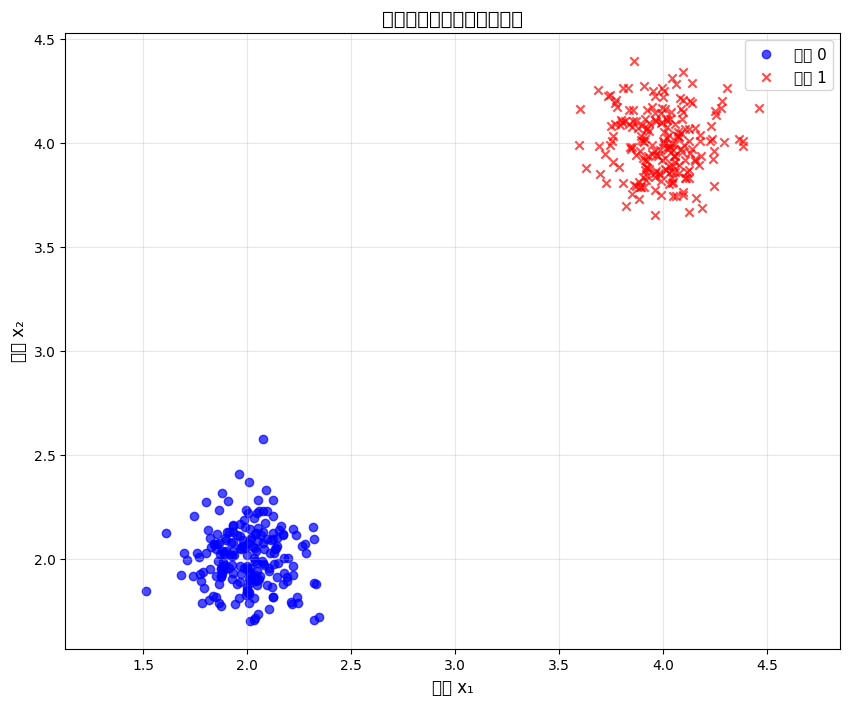

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

print("="*60)
print("二分类逻辑回归从零实现")
print("="*60)

# ========== 生成线性可分数据 ==========
def generate_linear_data(n_samples=200, noise=0.1):
    """
    生成线性可分的二分类数据
    类别0: 以 (2, 2) 为中心
    类别1: 以 (4, 4) 为中心
    """
    # 类别0
    x0 = np.random.randn(n_samples, 2) * noise + np.array([2, 2])
    y0 = np.zeros(n_samples)
    
    # 类别1
    x1 = np.random.randn(n_samples, 2) * noise + np.array([4, 4])
    y1 = np.ones(n_samples)
    
    # 合并数据
    X = np.vstack([x0, x1])
    y = np.hstack([y0, y1])
    
    return X, y

# 生成训练数据
X_train, y_train = generate_linear_data(n_samples=200, noise=0.15)

print(f"训练数据信息:")
print(f"特征维度: {X_train.shape[1]}")
print(f"样本数量: {X_train.shape[0]}")
print(f"类别分布: 类别0 = {sum(y_train==0)}, 类别1 = {sum(y_train==1)}")

# 可视化训练数据
plt.figure(figsize=(10, 8))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            c='blue', marker='o', label='类别 0', alpha=0.7)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            c='red', marker='x', label='类别 1', alpha=0.7)
plt.xlabel('特征 x₁', fontsize=12)
plt.ylabel('特征 x₂', fontsize=12)
plt.title('训练数据分布（线性可分）', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

测试数据信息:
样本数量: 200
类别分布: 类别0 = 100, 类别1 = 100


C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\2207365194.py:12: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


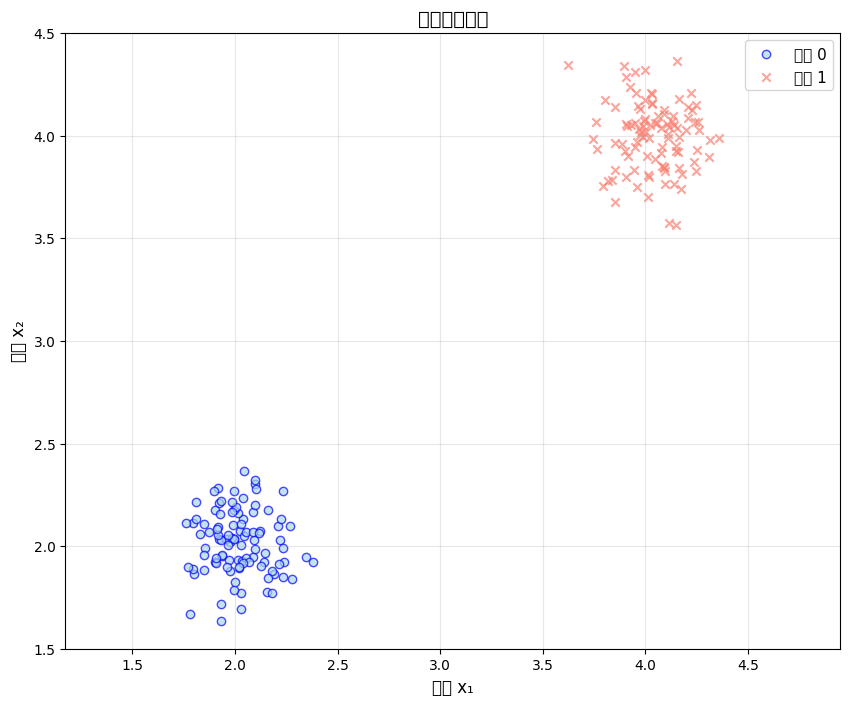

In [2]:
# 生成测试数据（新生成100个样本）
X_test, y_test = generate_linear_data(n_samples=100, noise=0.15)

print(f"测试数据信息:")
print(f"样本数量: {X_test.shape[0]}")
print(f"类别分布: 类别0 = {sum(y_test==0)}, 类别1 = {sum(y_test==1)}")

# 可视化测试数据
plt.figure(figsize=(10, 8))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
            c='lightblue', marker='o', label='类别 0', alpha=0.7, edgecolors='blue')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
            c='salmon', marker='x', label='类别 1', alpha=0.7, edgecolors='red')
plt.xlabel('特征 x₁', fontsize=12)
plt.ylabel('特征 x₂', fontsize=12)
plt.title('测试数据分布', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [3]:
class LogisticRegression:
    """从零实现的二分类逻辑回归"""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        """
        初始化参数
        learning_rate: 学习率
        n_iterations: 迭代次数
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.W = None  # 权重
        self.b = None  # 偏置
        self.losses = []  # 记录损失历史
        
    def sigmoid(self, z):
        """
        Sigmoid 激活函数
        z: 线性输出 (n_samples,)
        返回: 概率值 (0, 1)
        """
        # 数值稳定性：限制 z 的范围
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_pred, y_true):
        """
        二元交叉熵损失函数
        y_pred: 预测概率 (n_samples,)
        y_true: 真实标签 (n_samples,)
        返回: 平均损失
        """
        # 避免 log(0)
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # 二元交叉熵公式
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def compute_gradients(self, X, y_pred, y_true):
        """
        计算梯度
        X: 输入特征 (n_samples, n_features)
        y_pred: 预测概率 (n_samples,)
        y_true: 真实标签 (n_samples,)
        返回: dW, db
        """
        n_samples = X.shape[0]
        
        # 计算误差
        error = y_pred - y_true
        
        # 计算梯度
        dW = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples
        
        return dW, db
    
    def update_parameters(self, dW, db):
        """使用梯度下降更新参数"""
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    
    def forward(self, X):
        """
        前向传播
        X: 输入特征 (n_samples, n_features)
        返回: 预测概率 (n_samples,)
        """
        # 线性部分: z = X·W + b
        z = np.dot(X, self.W) + self.b
        # 激活函数
        return self.sigmoid(z)
    
    def train(self, X, y):
        """
        训练模型
        X: 训练特征 (n_samples, n_features)
        y: 训练标签 (n_samples,)
        """
        # 初始化参数
        n_samples, n_features = X.shape
        self.W = np.random.randn(n_features) * 0.01
        self.b = 0.0
        
        print(f"\n初始化参数:")
        print(f"W 形状: {self.W.shape}")
        print(f"b: {self.b}")
        print(f"学习率: {self.learning_rate}")
        print(f"迭代次数: {self.n_iterations}")
        
        print("\n" + "="*60)
        print("开始训练")
        print("="*60)
        
        for i in range(self.n_iterations):
            # 前向传播
            y_pred = self.forward(X)
            
            # 计算损失
            loss = self.binary_cross_entropy(y_pred, y)
            self.losses.append(loss)
            
            # 计算梯度
            dW, db = self.compute_gradients(X, y_pred, y)
            
            # 更新参数
            self.update_parameters(dW, db)
            
            # 打印进度
            if (i + 1) % 100 == 0:
                accuracy = self.accuracy(X, y)
                print(f"Iteration {i+1:4d}/{self.n_iterations} | "
                      f"Loss: {loss:.6f} | "
                      f"Accuracy: {accuracy:.4f} | "
                      f"W: [{self.W[0]:.4f}, {self.W[1]:.4f}] | "
                      f"b: {self.b:.4f}")
        
        print("训练完成！")
    
    def predict_proba(self, X):
        """预测概率"""
        return self.forward(X)
    
    def predict(self, X, threshold=0.5):
        """
        预测类别
        X: 输入特征
        threshold: 分类阈值
        返回: 预测类别 (0 或 1)
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 创建模型
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)

# 训练模型
model.train(X_train, y_train)


初始化参数:
W 形状: (2,)
b: 0.0
学习率: 0.1
迭代次数: 1000

开始训练
Iteration  100/1000 | Loss: 0.473176 | Accuracy: 0.9475 | W: [0.2995, 0.2908] | b: -1.2613
Iteration  200/1000 | Loss: 0.360411 | Accuracy: 1.0000 | W: [0.4643, 0.4530] | b: -2.2939
Iteration  300/1000 | Loss: 0.285755 | Accuracy: 1.0000 | W: [0.6001, 0.5868] | b: -3.1339
Iteration  400/1000 | Loss: 0.234195 | Accuracy: 1.0000 | W: [0.7139, 0.6988] | b: -3.8321
Iteration  500/1000 | Loss: 0.197102 | Accuracy: 1.0000 | W: [0.8111, 0.7943] | b: -4.4244
Iteration  600/1000 | Loss: 0.169443 | Accuracy: 1.0000 | W: [0.8953, 0.8770] | b: -4.9359
Iteration  700/1000 | Loss: 0.148179 | Accuracy: 1.0000 | W: [0.9695, 0.9497] | b: -5.3844
Iteration  800/1000 | Loss: 0.131405 | Accuracy: 1.0000 | W: [1.0356, 1.0144] | b: -5.7828
Iteration  900/1000 | Loss: 0.117882 | Accuracy: 1.0000 | W: [1.0950, 1.0726] | b: -6.1406
Iteration 1000/1000 | Loss: 0.106777 | Accuracy: 1.0000 | W: [1.1490, 1.1253] | b: -6.4648
训练完成！


C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\1344684249.py:19: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from cur

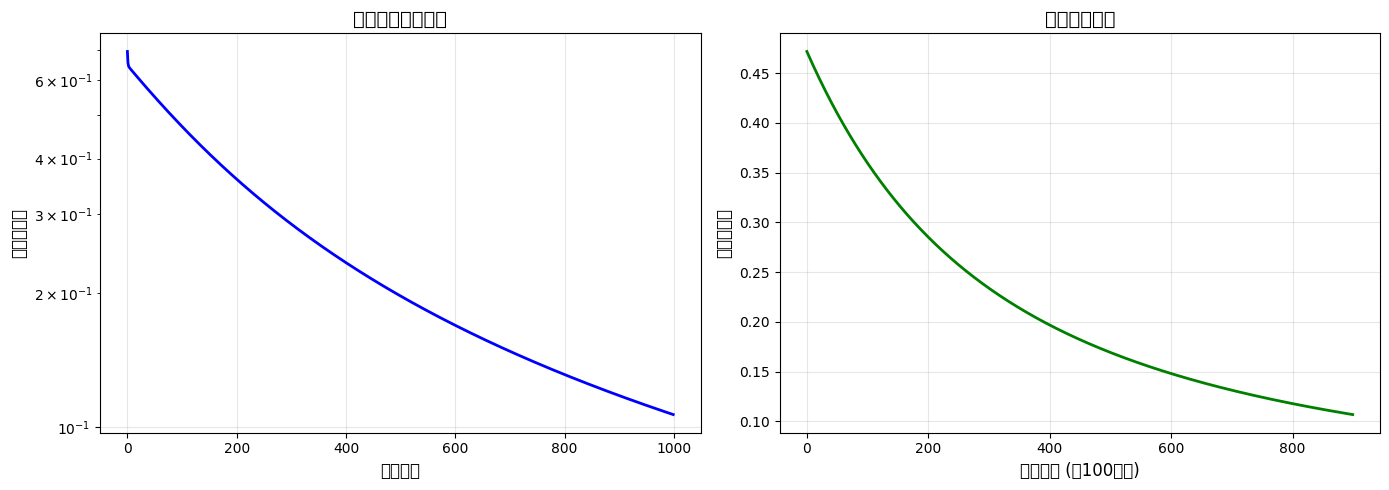


最终损失: 0.106777
初始损失: 0.694674
损失下降: 0.587897


In [4]:
# 绘制损失下降曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(model.losses, 'b-', linewidth=2)
axes[0].set_xlabel('迭代次数', fontsize=12)
axes[0].set_ylabel('交叉熵损失', fontsize=12)
axes[0].set_title('训练损失下降曲线', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # 对数坐标更清晰

# 损失变化（放大后100次迭代）
axes[1].plot(model.losses[100:], 'g-', linewidth=2)
axes[1].set_xlabel('迭代次数 (从100开始)', fontsize=12)
axes[1].set_ylabel('交叉熵损失', fontsize=12)
axes[1].set_title('损失下降细节', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n最终损失: {model.losses[-1]:.6f}")
print(f"初始损失: {model.losses[0]:.6f}")
print(f"损失下降: {model.losses[0] - model.losses[-1]:.6f}")

C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:24: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y==1, 0], X[y==1, 1],
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Lo

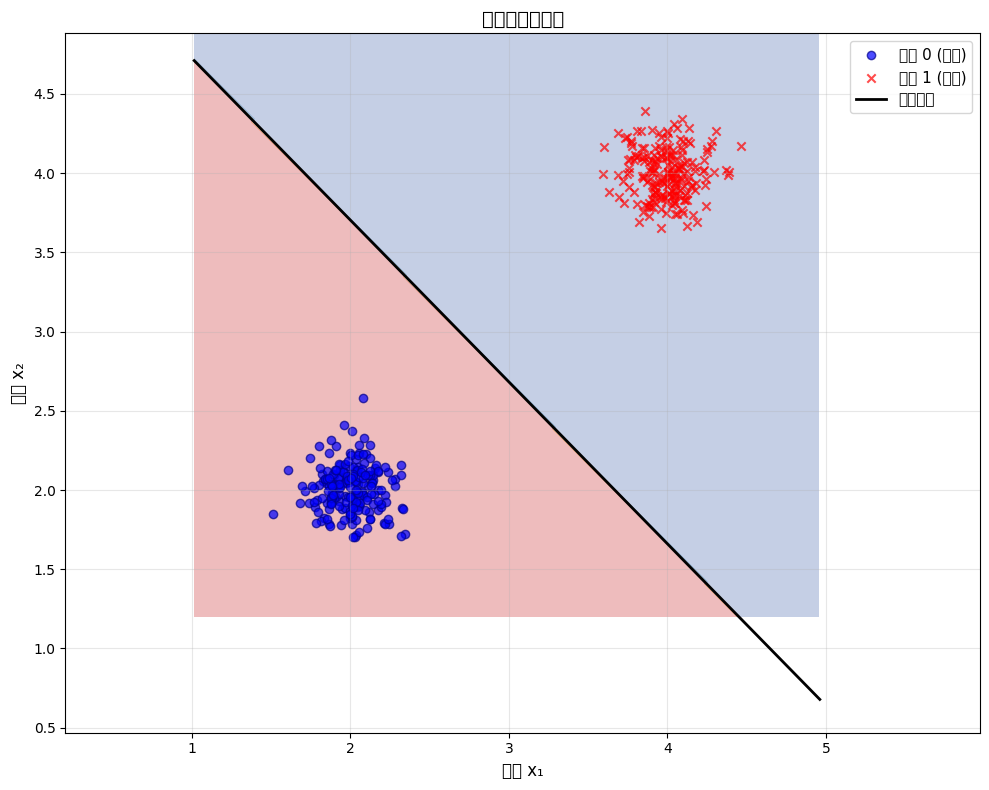

C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_66664\79424563.py:40: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from current font.
  plt.tight_layout()


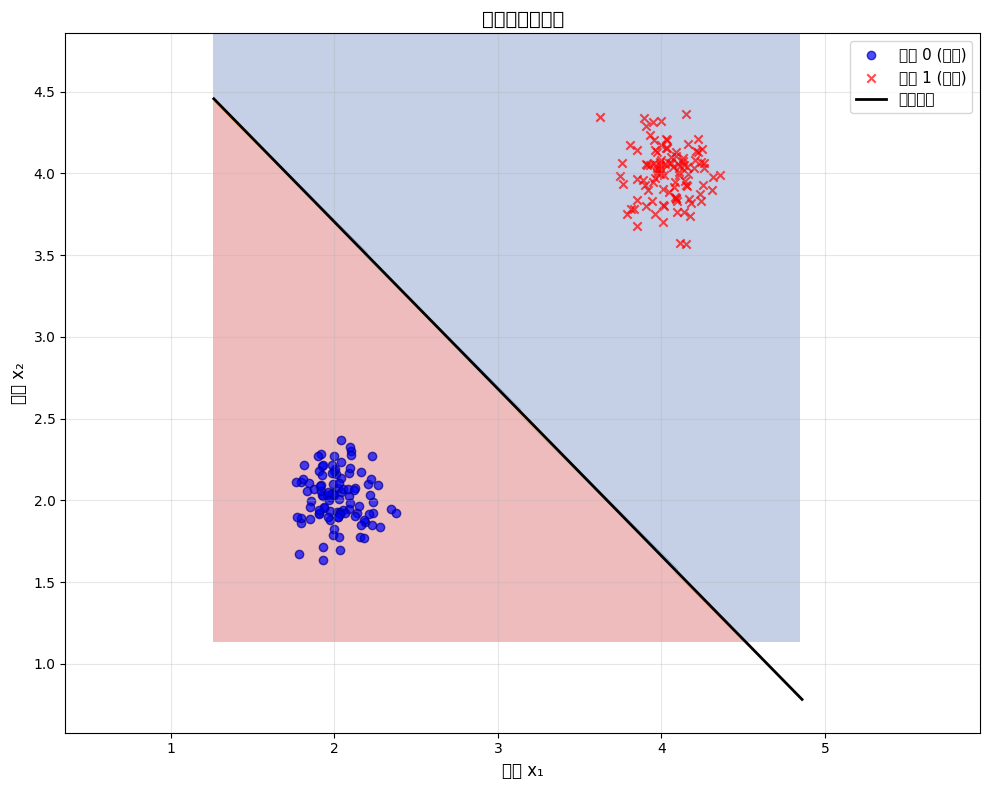

In [5]:
def plot_decision_boundary(model, X, y, title="决策边界"):
    """
    绘制决策边界
    """
    # 确定绘图范围
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 创建网格
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # 预测网格点的类别
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], 
                c='blue', marker='o', label='类别 0 (实际)', alpha=0.7, edgecolors='darkblue')
    plt.scatter(X[y==1, 0], X[y==1, 1], 
                c='red', marker='x', label='类别 1 (实际)', alpha=0.7, edgecolors='darkred')
    
    # 绘制决策边界线（概率=0.5）
    # 计算决策边界方程: w0*x + w1*y + b = 0
    if model.W[1] != 0:
        x_boundary = np.linspace(x_min, x_max, 100)
        y_boundary = -(model.W[0] * x_boundary + model.b) / model.W[1]
        plt.plot(x_boundary, y_boundary, 'k-', linewidth=2, label='决策边界')
    
    plt.xlabel('特征 x₁', fontsize=12)
    plt.ylabel('特征 x₂', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# 绘制训练集的决策边界
plot_decision_boundary(model, X_train, y_train, "训练集决策边界")

# 绘制测试集的决策边界
plot_decision_boundary(model, X_test, y_test, "测试集决策边界")

In [7]:
# 在训练集和测试集上进行预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算准确率
train_accuracy = model.accuracy(X_train, y_train)
test_accuracy = model.accuracy(X_test, y_test)

# 计算其他评估指标
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("模型评估结果")
print("="*60)

print(f"\n训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



模型评估结果

训练集准确率: 1.0000 (100.00%)
测试集准确率: 1.0000 (100.00%)
